<a href="https://colab.research.google.com/github/F-Boivin/ProyectoDSParte1-Felipe-Boivin/blob/main/ProyectoDSParte1_Felipe_Boivin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Data Science I — Parte I
## Análisis exploratorio del dataset UCI Bank Marketing

**Alumno:** Felipe Boivin

**Curso:** Data Science I — Comisión 90505

**Fecha de entrega:** 03/03/2026

**Dataset:** [bank.csv — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

## Abstract

El presente trabajo tiene como objetivo realizar un análisis exploratorio de datos (EDA) sobre el dataset "Bank Marketing", disponible en el repositorio UCI Machine Learning Repository. Este conjunto de datos contiene información relacionada con campañas de marketing telefónico llevadas a cabo por una institución bancaria portuguesa, cuyo fin era promover la contratación de depósitos a plazo fijo entre sus clientes.

El dataset cuenta con 4521 registros y 17 variables que abarcan información demográfica de los clientes (edad, estado civil, nivel educativo, ocupación), su situación financiera (saldo en cuenta, si posee crédito hipotecario o préstamo personal) y datos relativos a la campaña de contacto (tipo de comunicación, día y mes del último contacto, duración de la llamada, cantidad de contactos realizados). También incluye información sobre campañas previas y una variable objetivo binaria que indica si el cliente contrató o no el depósito a plazo.

El análisis se estructura en torno a una pregunta problema central: ¿qué factores del perfil del cliente y de la estrategia de contacto influyen en la decisión de contratar un depósito a plazo fijo? Para responderla, se plantean cuatro hipótesis de interés: (H1) que los clientes casados presentan mayor tasa de contratación que los solteros, dado que se los suele asociar con mayor estabilidad financiera; (H2) que los clientes que contratan el depósito poseen un saldo promedio superior; (H3) que las llamadas de mayor duración se asocian con una mayor probabilidad de contratación; y (H4) que los clientes que tuvieron un resultado exitoso en campañas anteriores tienen mayor tendencia a volver a contratar.

A través de resúmenes numéricos y visualizaciones — incluyendo gráficos de barras agrupadas, boxplots e histogramas — se busca explorar estas relaciones, identificar patrones y evaluar si los datos respaldan o refutan cada hipótesis planteada. También se realizará una identificación de valores perdidos, tanto explícitos como encubiertos bajo la categoría "unknown" presente en algunas variables categóricas del dataset.

## Preguntas e hipótesis de interés

### Pregunta problema central

> ¿Qué factores del perfil del cliente y de la estrategia de contacto influyen en la decisión de contratar un depósito a plazo fijo?

### Hipótesis

**H1 — Estado civil y suscripción:**
Los clientes casados, al tener mayor estabilidad financiera, contratan el depósito en mayor proporción que los solteros.

**H2 — Saldo y contratación:**
Los clientes que contratan el depósito poseen un saldo promedio en cuenta significativamente mayor que los que no lo hacen.

**H3 — Duración de la llamada y resultado:**
Las llamadas de mayor duración se asocian con una mayor probabilidad de contratación del depósito.

**H4 — Resultado de campaña previa:**
Los clientes que tuvieron un resultado exitoso en campañas de marketing anteriores presentan mayor tendencia a contratar nuevamente.

## Importacion librerias y set de datos

In [12]:
# Importar librerías, Pandas y Matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Importar set de datos desde GITHUB
url = 'https://raw.githubusercontent.com/F-Boivin/ProyectoDSParte1-Felipe-Boivin/main/bank%20(1).csv'
df = pd.read_csv(url, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Exploracion inicial

In [14]:
# Dimensiones del dataset
print('Dimensiones del dataset:', df.shape)
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()

# Tipos de dato por columna
print('Tipos de dato:')
print(df.dtypes)

Dimensiones del dataset: (4521, 17)
Filas: 4521 | Columnas: 17

Tipos de dato:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


## Analisis de valores perdidos

In [15]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [16]:
# Verificación de nulos formales
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [17]:
# Detección de valores "unknown" en variables categóricas
categoricas = df.select_dtypes(include='object').columns

print('Cantidad y porcentaje de valores "unknown" por variable categórica:\n')
for col in categoricas:
    cant_unknown = (df[col] == 'unknown').sum()
    if cant_unknown > 0:
        porcentaje = round(cant_unknown / len(df) * 100, 2)
        print(f'  {col}: {cant_unknown} valores "unknown" ({porcentaje}%)')

Cantidad y porcentaje de valores "unknown" por variable categórica:

  job: 38 valores "unknown" (0.84%)
  education: 187 valores "unknown" (4.14%)
  contact: 1324 valores "unknown" (29.29%)
  poutcome: 3705 valores "unknown" (81.95%)


## Interpretacion valores perdidos
No se detectan valores nulos formales (NaN) en ninguna columna del dataset.

Sin embargo, al inspeccionar las variables categóricas se identifican valores "unknown" que representan datos faltantes encubiertos.
Estos se concentran en las variables contact, poutcome y education.

Poutcome presenta un alto porcentaje de valores desconocidos. En el dataset original, esta variable esta definida como "outcome of the previous marketing campaign", imagino que el alto porcentaje obedece a que se trataria de clientes que no fueron contactados en campañas anteriores.

# Resumen estadistico del dataset

In [18]:
# Estadísticos de variables numéricas
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [19]:
# Frecuencias de variables categóricas
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


## Interpretacion del resumen estadistico
* La edad promedio de los clientes es de aproximadamente 41 años, con un rango entre 19 y 87.
* El saldo en cuenta (balance) presenta gran dispersión: la media es cercana a 1423 pero la mediana (448) es mucho menor, lo que indica una distribución asimétrica con algunos clientes con saldos muy elevados.
* La duración promedio de las llamadas (duration) ronda los 264 segundos (~4.4 minutos), aunque también muestra alta variabilidad.
* En cuanto a las categóricas:
  * la ocupación más frecuente es management,
  * el estado civil predominante es married,
  * la variable objetivo 'y' muestra que la mayoría de los clientes no contrató el depósito.
  * Resulta llamativa la concentración de casos en el mes de mayo, que representa aproximadamente el 30% del total de registros del dataset. Esto sugiere que el banco intensificó significativamente sus campañas telefónicas durante ese mes. Sería interesante analizar si la tasa de contratación varía según el mes de contacto y si mayo, a pesar de concentrar más llamadas, mantiene una tasa de éxito comparable al resto de los meses.

## H1 — Estado civil y suscripción
**Hipótesis:** Los clientes casados, al tener mayor estabilidad financiera, contratan el depósito en mayor proporción que los solteros.

In [20]:
# Tabla cruzada: proporción de contratación por estado civil
ct_marital = pd.crosstab(df['marital'], df['y'], normalize='index') * 100
print(ct_marital.round(2))

y            no    yes
marital               
divorced  85.42  14.58
married   90.10   9.90
single    86.04  13.96


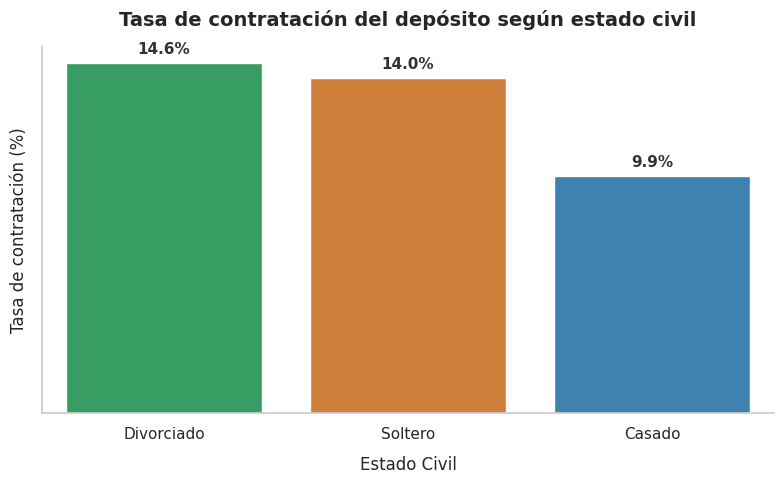

In [32]:
# Extraemos la columna 'yes' (los que sí contrataron)
tasa_yes = ct_marital['yes']

# Ordenar datos de mayor a menor
tasa_yes_sorted = tasa_yes.sort_values(ascending=False)

# Configurar estilo
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 5))

# Crear gráfico (Colab me de un WARNING, se soluciono con hue y legend=False)
sns.barplot(x=tasa_yes_sorted.index, y=tasa_yes_sorted.values,
            hue=tasa_yes_sorted.index, legend=False,
            palette=['#27ae60', '#e67e22', '#2e86c1'], ax=ax)

# Traducir las etiquetas (otro warning, se fijaron los ticks primero)
nombres_es = {'divorced': 'Divorciado', 'single': 'Soltero', 'married': 'Casado'}
ax.set_xticks(range(len(tasa_yes_sorted))) # Fijamos las posiciones (0, 1, 2)
ax.set_xticklabels([nombres_es.get(x, x) for x in tasa_yes_sorted.index], fontsize=11)

# Agregar las etiquetas de datos (porcentajes)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#333333',
                xytext=(0, 5), textcoords='offset points')

# Limpieza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Ajustar títulos y etiquetas
plt.title('Tasa de contratación del depósito según estado civil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estado Civil', fontsize=12, labelpad=10)
plt.ylabel('Tasa de contratación (%)', fontsize=12, labelpad=10)

# Ocultar los números del eje Y
ax.set_yticks([])

plt.tight_layout()
plt.show()

**Interpretación:** Contrariamente a lo esperado, los datos no respaldan la hipótesis H1.
Porcentualmente los clientes solteros y los divorciados presentan una tasa de contratación levemente superior a la de los casados.
La supuesta mayor estabilidad financiera asociada al matrimonio no se traduce en una mayor propensión a contratar el depósito a plazo.

La hipótesis **no se comprueba**.

## H2 — Saldo y contratación
**Hipótesis:** Los clientes que contratan el depósito poseen un saldo promedio en cuenta significativamente mayor que los que no lo hacen.

In [23]:
# Resumen numérico: balance agrupado por contratación
print(df.groupby('y')['balance'].describe().round(2))

      count     mean      std     min    25%    50%     75%      max
y                                                                   
no   4000.0  1403.21  3075.35 -3313.0   61.0  419.5  1407.0  71188.0
yes   521.0  1571.96  2444.40 -1206.0  171.0  710.0  2160.0  26965.0


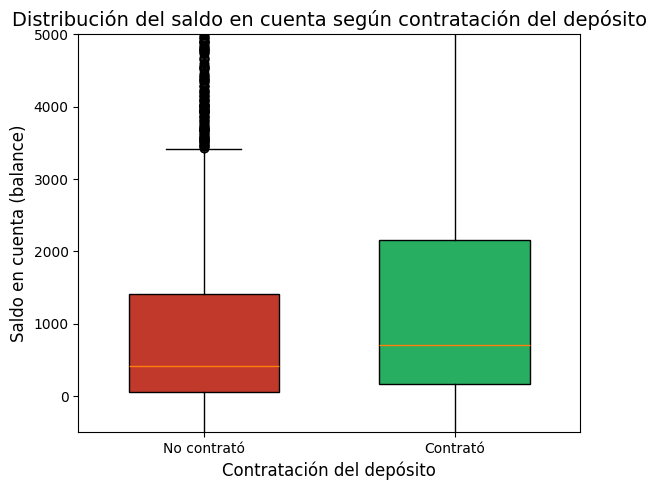

In [24]:
# Boxplot: distribución del saldo según contratación (sin outliers extremos)
fig, ax = plt.subplots(figsize=(6, 5))

datos_no = df[df['y'] == 'no']['balance']
datos_yes = df[df['y'] == 'yes']['balance']

bp = ax.boxplot([datos_no, datos_yes], tick_labels=['No contrató', 'Contrató'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#c0392b')
bp['boxes'][1].set_facecolor('#27ae60')

plt.ylim(-500, 5000)
plt.title('Distribución del saldo en cuenta según contratación del depósito', fontsize=14)
plt.xlabel('Contratación del depósito', fontsize=12)
plt.ylabel('Saldo en cuenta (balance)', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación:** Los datos respaldan la hipótesis H2. Los clientes que contrataron el depósito presentan un saldo promedio y una mediana superiores a los que no contrataron. Si bien ambos grupos muestran alta dispersión y valores atípicos elevados, la diferencia en las medidas de tendencia central es clara.

La hipótesis **se comprueba**.

## H3 — Duración de la llamada y resultado
**Hipótesis:** Las llamadas de mayor duración se asocian con una mayor probabilidad de contratación del depósito.

In [25]:
# Resumen numérico: duración agrupada por contratación
print(df.groupby('y')['duration'].describe().round(2))

      count    mean     std   min    25%    50%    75%     max
y                                                             
no   4000.0  226.35  210.31   4.0   96.0  167.0  283.0  3025.0
yes   521.0  552.74  390.33  30.0  260.0  442.0  755.0  2769.0


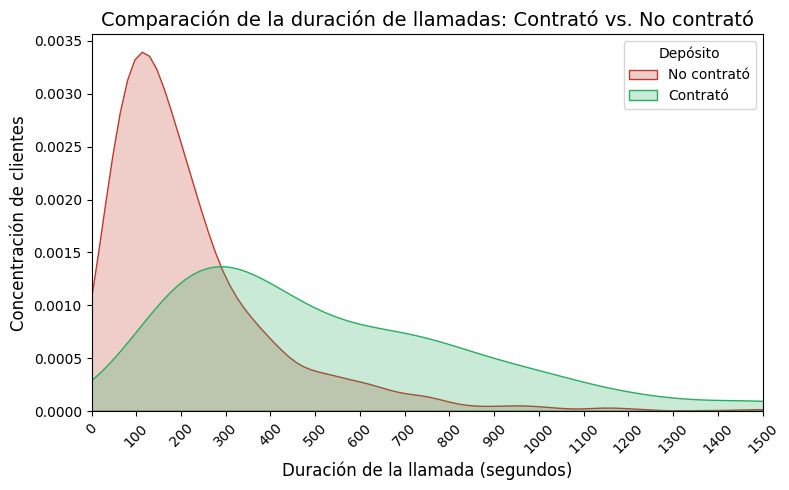

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(data=df[df['y'] == 'no'], x='duration', fill=True, color='#c0392b', label='No contrató', ax=ax)
sns.kdeplot(data=df[df['y'] == 'yes'], x='duration', fill=True, color='#27ae60', label='Contrató', ax=ax)

ax.set_xlim(0, 1500)
ax.set_xticks(range(0, 1501, 100))
ax.tick_params(axis='x', rotation=45)

plt.title('Comparación de la duración de llamadas: Contrató vs. No contrató', fontsize=14)
plt.xlabel('Duración de la llamada (segundos)', fontsize=12)
plt.ylabel('Concentración de clientes', fontsize=12)
plt.legend(title='Depósito', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** Los datos respaldan fuertemente la hipótesis H3. Las llamadas que resultaron en contratación tienen una duración promedio considerablemente mayor que las que no. En el histograma se observa que los clientes que no contrataron se concentran en llamadas cortas (menos de 200 segundos), mientras que los que sí contrataron presentan una distribución más extendida hacia duraciones mayores. Esto tiene sentido intuitivo: una llamada más larga sugiere mayor interés y engagement del cliente con la propuesta.

La hipótesis **se comprueba**.

## H4 — Resultado de campaña previa
**Hipótesis:** Los clientes que tuvieron un resultado exitoso en campañas de marketing anteriores presentan mayor tendencia a contratar nuevamente.

In [27]:
# Tabla cruzada: proporción de contratación por resultado de campaña previa
ct_poutcome = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
print(ct_poutcome.round(2))

y            no    yes
poutcome              
failure   87.14  12.86
other     80.71  19.29
success   35.66  64.34
unknown   90.90   9.10


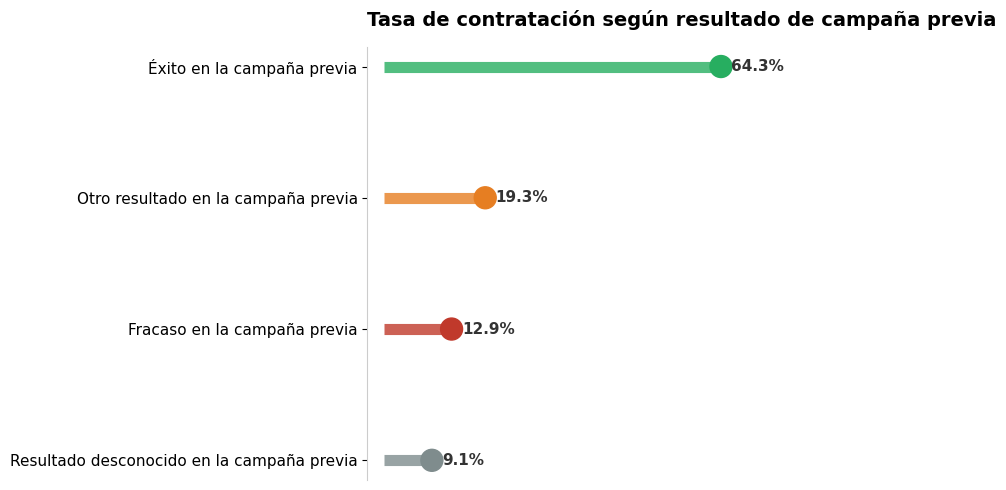

In [28]:
# Calcular la tasa de contratación ('y' == 'yes') según 'poutcome'
tasa_yes_pout = (df['y'] == 'yes').groupby(df['poutcome']).mean() * 100

# 1. Ordenar datos de menor a mayor
tasa_yes_pout_sorted = tasa_yes_pout.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

# 2. Definir colores
colores_dict = {'success': '#27ae60', 'other': '#e67e22', 'failure': '#c0392b', 'unknown': '#7f8c8d'}
colores = [colores_dict[x] for x in tasa_yes_pout_sorted.index]

# 3. Palito
ax.hlines(y=range(len(tasa_yes_pout_sorted)), xmin=0, xmax=tasa_yes_pout_sorted.values,
          color=colores, linewidth=8, alpha=0.8)

# 4. Caramelo
ax.scatter(tasa_yes_pout_sorted.values, range(len(tasa_yes_pout_sorted)),
           color=colores, s=250, zorder=3)

# 5. Etiquetas eje Y
nombres_es = {'success': 'Éxito en la campaña previa', 'other': 'Otro resultado en la campaña previa', 'failure': 'Fracaso en la campaña previa', 'unknown': 'Resultado desconocido en la campaña previa'}
ax.set_yticks(range(len(tasa_yes_pout_sorted)))
ax.set_yticklabels([nombres_es.get(x, x) for x in tasa_yes_pout_sorted.index], fontsize=11)

# 6. Etiquetas de datos
for i, val in enumerate(tasa_yes_pout_sorted.values):
    ax.text(val + 2, i, f'{val:.1f}%', va='center',
            fontsize=11, fontweight='bold', color='#333333')

# 7. Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False) # Quitamos la línea de abajo
ax.spines['left'].set_color('#cccccc')

# Ocultar eje x
ax.set_xticks([])

# Títulos
plt.title('Tasa de contratación según resultado de campaña previa',
          fontsize=14, fontweight='bold', loc='left', pad=15)

plt.tight_layout()
plt.show()

**Interpretación:** Los datos respaldan fuertemente la hipótesis H4. Los clientes cuya campaña previa fue exitosa ("success") presentan una tasa de contratación muy superior al resto de las categorías. En contraste, los clientes con resultado previo "failure" o "unknown" muestran tasas significativamente menores. Esto indica que la experiencia positiva previa con el banco es un fuerte predictor de contratación futura. Cabe destacar que la categoría "unknown" concentra la mayoría de los casos, lo cual se relaciona con los valores perdidos encubiertos identificados en el Paso 7.

La hipótesis **se comprueba**.

## Análisis complementario — Concentración de casos en mayo

En la exploración inicial se observó que el mes de mayo concentra aproximadamente el 30% de los registros del dataset. Surge la pregunta: ¿esta concentración afecta los resultados observados? Para evaluarlo, se compara la tasa de contratación de mayo contra el resto de los meses.

In [29]:
# Crear variable auxiliar: mayo vs resto
df['es_mayo'] = df['month'].apply(lambda x: 'Mayo' if x == 'may' else 'Resto')

# Tasa de contratación: mayo vs resto
ct_mayo = pd.crosstab(df['es_mayo'], df['y'], normalize='index') * 100
print(ct_mayo.round(2))
print()

# Cantidad de registros
print('Cantidad de registros:')
print(df['es_mayo'].value_counts())

y           no    yes
es_mayo              
Mayo     93.35   6.65
Resto    86.30  13.70

Cantidad de registros:
es_mayo
Resto    3123
Mayo     1398
Name: count, dtype: int64


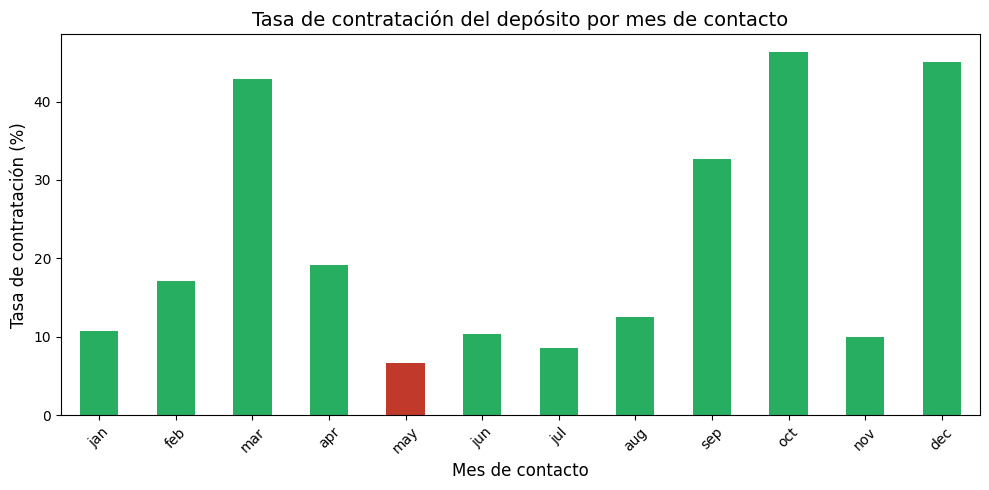

In [30]:
# Gráfico: tasa de contratación por mes
tasa_mes = pd.crosstab(df['month'], df['y'], normalize='index')['yes'] * 100

# Ordenar meses cronológicamente
orden_meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
tasa_mes = tasa_mes.reindex(orden_meses)

# Colores: mayo en rojo, resto en verde
colores = ['#27ae60' if mes != 'may' else '#c0392b' for mes in tasa_mes.index]

fig, ax = plt.subplots(figsize=(10, 5))
tasa_mes.plot(kind='bar', color=colores, ax=ax)

plt.title('Tasa de contratación del depósito por mes de contacto', fontsize=14)
plt.xlabel('Mes de contacto', fontsize=12)
plt.ylabel('Tasa de contratación (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

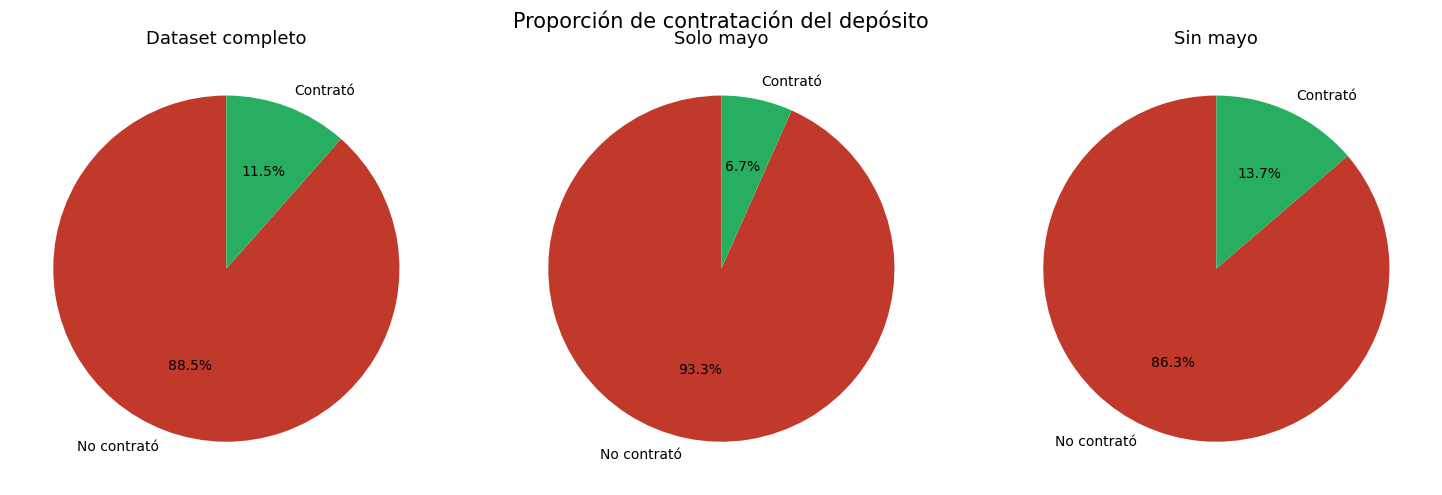

In [31]:
# Gráficos de torta: proporción de contratación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colores = ['#c0392b', '#27ae60']
labels = ['No contrató', 'Contrató']

# 1. Dataset completo
total = df['y'].value_counts()
axes[0].pie(total, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90)
axes[0].set_title('Dataset completo', fontsize=13)

# 2. Solo mayo
solo_mayo = df[df['month'] == 'may']['y'].value_counts()
axes[1].pie(solo_mayo, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Solo mayo', fontsize=13)

# 3. Sin mayo
sin_mayo = df[df['month'] != 'may']['y'].value_counts()
axes[2].pie(sin_mayo, labels=labels, autopct='%1.1f%%', colors=colores, startangle=90)
axes[2].set_title('Sin mayo', fontsize=13)

plt.suptitle('Proporción de contratación del depósito', fontsize=15)
plt.tight_layout()
plt.show()

**Interpretación:** El análisis revela que mayo, a pesar de concentrar la mayor cantidad de contactos, presenta una de las tasas de contratación más bajas. Esto sugiere que la intensificación de llamadas en ese mes no fue acompañada por una mayor efectividad, sino todo lo contrario: el volumen masivo de contactos posiblemente incluyó clientes con menor predisposición a contratar. Este hallazgo es relevante porque mayo está sobrerepresentado en el dataset (~30% de los registros), y su baja tasa de conversión arrastra hacia abajo la tasa de contratación general. Meses con menos contactos, como marzo, septiembre y octubre, muestran tasas de éxito considerablemente superiores, lo que podría orientar futuras estrategias de campaña.

## Conclusiones finales

A lo largo de este análisis exploratorio se evaluaron cuatro hipótesis vinculadas a la pregunta central: ¿qué factores influyen en la contratación de un depósito a plazo fijo?

**Resultados de las hipótesis:**

- **H1 — Estado civil:** No se comprueba. Los clientes solteros presentan una tasa de contratación levemente superior a los casados, contradiciendo la suposición de que la estabilidad asociada al matrimonio favorecería la contratación.
- **H2 — Saldo en cuenta:** Se comprueba. Los clientes que contrataron el depósito presentan un saldo promedio y una mediana superiores a los que no contrataron.
- **H3 — Duración de la llamada:** Se comprueba fuertemente. Las llamadas más largas se asocian con mayor contratación, lo que sugiere que el engagement durante la conversación es un factor clave.
- **H4 — Resultado de campaña previa:** Se comprueba fuertemente. Los clientes con experiencia exitosa en campañas anteriores tienen una tasa de contratación muy superior al resto.

**Análisis complementario — Mayo:**
Se identificó que mayo concentra ~30% de los registros y presenta una de las tasas de contratación más bajas.

## Comentario final sobre las hipótesis y propuesta para futuros análisis

La forma en la cual se efectuó la pregunta central, **¿Qué factores del perfil del cliente y de la estrategia de contacto influyen en la decisión de contratar un depósito a plazo fijo?** pareciera llevarnos inevitablemente hacia un patrón de hipótesis repetitivo: *"variable X se relaciona con y (sí/no)"*.

Para una futura exploración podría intentarse otro tipo de estructura de hipótesis, quizá no tan útiles para responder la pregunta central del dataset pero no carentes de relevancia general, hipótesis tales como:

1. Comparación entre subgrupos (sin involucrar la variable target):

*"Los clientes jubilados tienen un saldo promedio mayor que los trabajadores blue-collar."*

2. Umbral o punto de corte:

*"Existe una duración mínima de llamada por debajo de la cual prácticamente ningún cliente contrata."*

3. Interacción entre variables:

*"El efecto del saldo sobre la contratación es distinto según el nivel educativo del cliente."*

4. Distribución:

*"La edad de los clientes contactados sigue una distribución normal."*

5. Temporal/estacional:

*"Los meses del último trimestre del año presentan mejor tasa de conversión que los del primer trimestre."*

6. Proporcionalidad:

*"A mayor cantidad de contactos en la misma campaña, menor probabilidad de contratación (efecto de saturación)."*